### (A) Analyze Dataset And Handle Issues

Link Video Penjelasan 
https://drive.google.com/drive/folders/1MZgxNjJfUJcnm7r29bPhZBD28eKmKgfj?usp=drive_link

ImageDataGenerator digunakan untuk memuat dan menormalisasi data gambar dengan mengubah nilai piksel ke rentang 0–1.
Data training dibaca dari direktori dan disiapkan dalam bentuk batch tanpa label karena autoencoder hanya mempelajari rekonstruksi gambar.


In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

IMG_SIZE = (100, 100)
BATCH_SIZE = 32

datagen = ImageDataGenerator(rescale=1./255)

train_data = datagen.flow_from_directory(
    "3/train",              
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode=None,
    shuffle=True
)


Found 2778 images belonging to 6 classes.


### (B) Autoencoder (Encoder - Encoder)

Generator ini disusun agar data gambar yang sama digunakan sebagai input dan target keluaran.
Hal ini sesuai dengan prinsip autoencoder, yaitu mempelajari rekonstruksi data dari representasi internalnya sendiri.


In [3]:
def autoencoder_generator(generator):
    while True:
        x = next(generator)
        yield x, x   # input = output

auto_train_data = autoencoder_generator(train_data)

Encoder menggunakan beberapa lapisan Convolution dan MaxPooling untuk mengekstraksi fitur penting dan mereduksi dimensi gambar.
Decoder kemudian merekonstruksi kembali gambar ke ukuran semula menggunakan Convolution dan UpSampling, dengan aktivasi sigmoid untuk menghasilkan nilai piksel 0–1.


In [4]:
input_img = Input(shape=(100, 100, 3))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)

encoded = x


In [5]:
x = Conv2D(128, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)


In [6]:
autoencoder = Model(input_img, decoded)

autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 25, 25, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 50, 50, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 100, 100, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,355 (1.21 MB)

 Trainable params: 316,355 (1.21 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
EPOCHS = 15

history = autoencoder.fit(
    auto_train_data,
    steps_per_epoch=100,
    epochs=EPOCHS
)


Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 211ms/step - loss: 0.0279
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 202ms/step - loss: 0.0061
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 214ms/step - loss: 0.0043
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 219ms/step - loss: 0.0036
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 199ms/step - loss: 0.0032
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 195ms/step - loss: 0.0031
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 194ms/step - loss: 0.0026
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 194ms/step - loss: 0.0027
Epoch 9/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 194ms/step - loss: 0.0024
Epoch 10/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 196ms/step - loss: 0.0023
Epoch 11/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 194ms/step - loss: 0.0024
Epoch 12/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 194ms/step - loss: 0.0021
Epoch 13/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 194ms/step - loss: 0.0021
Epoch 14/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 194ms/step - loss: 0.0020
Epoch 15/15
100

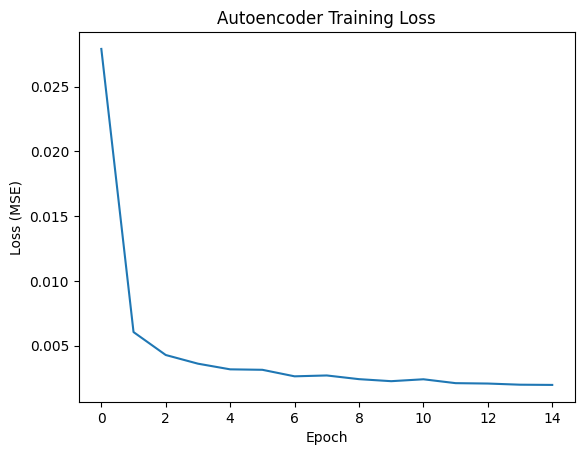

In [8]:
plt.plot(history.history['loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Autoencoder Training Loss")
plt.show()


Grafik menunjukkan bahwa nilai training loss (MSE) menurun tajam pada awal epoch dan kemudian melandai.
Hal ini menandakan bahwa autoencoder berhasil mempelajari representasi gambar dan mampu merekonstruksi input dengan baik.


### (C) Model Modification And Impact

In [23]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
import matplotlib.pyplot as plt
import os

In [24]:
def load_ae_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, image


In [25]:
def get_image_paths(root_dir):
    image_paths = []
    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if os.path.isdir(class_path):
            for fname in os.listdir(class_path):
                if fname.lower().endswith((".jpg", ".png", ".jpeg")):
                    image_paths.append(os.path.join(class_path, fname))
    return image_paths


Data gambar diambil dari direktori training dan validasi, kemudian diproses menggunakan `tf.data.Dataset` agar efisien dan sesuai dengan kebutuhan autoencoder.
Encoder mempelajari representasi laten gambar melalui Conv2D dan pooling, sementara decoder merekonstruksi kembali gambar ke bentuk semula menggunakan upsampling dan convolution.


In [28]:
TRAIN_DIR = r"3/train"
VAL_DIR   = r"3/validation"

IMG_SIZE = 100
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_paths = get_image_paths(TRAIN_DIR)
val_paths   = get_image_paths(VAL_DIR)

print("Train images:", len(train_paths))
print("Val images:", len(val_paths))

ae_train_ds = tf.data.Dataset.from_tensor_slices(train_paths)
ae_train_ds = ae_train_ds.map(load_ae_image, num_parallel_calls=AUTOTUNE)
ae_train_ds = ae_train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

ae_val_ds = tf.data.Dataset.from_tensor_slices(val_paths)
ae_val_ds = ae_val_ds.map(load_ae_image, num_parallel_calls=AUTOTUNE)
ae_val_ds = ae_val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


Train images: 2778
Val images: 2353


In [29]:
IMG_SIZE = 100

encoder_input = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = layers.Conv2D(32, 3, padding="same")(encoder_input)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU(0.2)(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU(0.2)(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(128, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU(0.2)(x)

latent = layers.Conv2D(256, 3, padding="same")(x)

encoder = Model(encoder_input, latent, name="Encoder")
encoder.summary()


Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 25, 25, 256)    │       295,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 389,312 (1.49 MB)

 Trainable params: 388,864 (1.48 MB)

 Non-trainable params: 448 (1.75 KB)

In [30]:
decoder_input = Input(shape=latent.shape[1:])

x = layers.UpSampling2D()(decoder_input)
x = layers.Conv2D(128, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU(0.2)(x)

x = layers.UpSampling2D()(x)
x = layers.Conv2D(64, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU(0.2)(x)

x = layers.Conv2D(32, 3, padding="same")(x)
x = layers.LeakyReLU(0.2)(x)

decoder_output = layers.Conv2D(3, 3, activation="sigmoid", padding="same")(x)

decoder = Model(decoder_input, decoder_output, name="Decoder")
decoder.summary()


Model: "Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 50, 50, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 50, 50, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 50, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 100, 100, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 100, 100, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 100, 100, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 100, 100, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 100, 100, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 388,931 (1.48 MB)

 Trainable params: 388,547 (1.48 MB)

 Non-trainable params: 384 (1.50 KB)

In [31]:
autoencoder_output = decoder(encoder(encoder_input))
autoencoder_ae = Model(encoder_input, autoencoder_output)

autoencoder_ae.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="mse"
)

autoencoder_ae.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder (Functional)            │ (None, 25, 25, 256)    │       389,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Functional)            │ (None, 100, 100, 3)    │       388,931 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 778,243 (2.97 MB)

 Trainable params: 777,411 (2.97 MB)

 Non-trainable params: 832 (3.25 KB)

In [32]:
history_ae = autoencoder_ae.fit(
    ae_train_ds,
    validation_data=ae_val_ds,
    epochs=15
)


Epoch 1/15
87/87 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - loss: 0.0208 - val_loss: 0.0835
Epoch 2/15
87/87 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - loss: 0.0058 - val_loss: 0.0551
Epoch 3/15
87/87 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - loss: 0.0047 - val_loss: 0.0272
Epoch 4/15
87/87 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - loss: 0.0040 - val_loss: 0.0119
Epoch 5/15
87/87 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - loss: 0.0036 - val_loss: 0.0050
Epoch 6/15
87/87 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - loss: 0.0034 - val_loss: 0.0034
Epoch 7/15
87/87 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - loss: 0.0031 - val_loss: 0.0029
Epoch 8/15
87/87 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - loss: 0.0030 - val_loss: 0.0026
Epoch 9/15
87/87 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - loss: 0.0028 - val_loss: 0.0027
Epoch 10/15
87/87 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - loss: 0.0028 - val_loss: 0.0024
Epoch 11/15
87/87 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - loss: 0.0025 - val_loss: 0.0023
Epoch 12/15
87/87 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - loss: 0.0

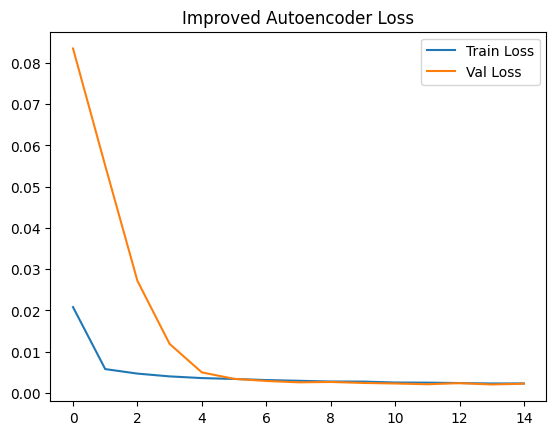

In [33]:
plt.plot(history_ae.history["loss"], label="Train Loss")
plt.plot(history_ae.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Improved Autoencoder Loss")
plt.show()


Grafik di atas menampilkan kurva loss pada Improved Autoencoder, di mana validation loss (oranye) menurun tajam dan konvergen dengan training loss (biru), menandakan model belajar dengan stabil tanpa indikasi overfitting yang signifikan.

### (D) Test Evaluation Using FID

In [45]:
import os
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub

from scipy.linalg import sqrtm
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tqdm import tqdm

inception = tf.keras.applications.InceptionV3(
    include_top=False,
    pooling="avg",
    input_shape=(299, 299, 3)
)

def preprocess_for_fid(images):
    images = tf.image.resize(images, (299, 299))
    images = preprocess_input(images)
    return images

def extract_features(images, batch_size=32):
    features = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size]
        batch = preprocess_for_fid(batch)
        features.append(inception(batch, training=False))
    return tf.concat(features, axis=0).numpy()

def calculate_fid(real_features, fake_features):
    mu1, sigma1 = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu2, sigma2 = fake_features.mean(axis=0), np.cov(fake_features, rowvar=False)

    diff = mu1 - mu2
    covmean = sqrtm(sigma1 @ sigma2)

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)
    return fid

def load_images_from_folder(folder, img_size=(100,100)):
    images = []
    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        if path.lower().endswith((".jpg", ".png", ".jpeg")):
            img = tf.keras.utils.load_img(path, target_size=img_size)
            img = tf.keras.utils.img_to_array(img) / 255.0
            images.append(img)
    return np.array(images)

def generate_images_autoencoder(model, real_images):
    return model.predict(real_images, verbose=0)

In [46]:
TEST_DIR = "3/test"
classes = os.listdir(TEST_DIR)

fid_scores = {}

for cls in classes:
    print(f"Computing FID for class: {cls}")

    real_imgs = load_images_from_folder(os.path.join(TEST_DIR, cls))
    real_imgs = real_imgs[:200]   # limit for speed

    # === AUTOENCODER ===
    fake_imgs = generate_images_autoencoder(autoencoder_ae, real_imgs)

    real_features = extract_features(real_imgs)
    fake_features = extract_features(fake_imgs)

    fid = calculate_fid(real_features, fake_features)
    fid_scores[cls] = fid


Computing FID for class: freshapples


C:\Users\Vanessa\AppData\Local\Temp\ipykernel_17908\2458453114.py:34: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = sqrtm(sigma1 @ sigma2)


Computing FID for class: freshbanana
Computing FID for class: freshoranges
Computing FID for class: rottenapples
Computing FID for class: rottenbanana
Computing FID for class: rottenoranges


In [47]:
print("\nFID Scores per Class:")
for cls, score in fid_scores.items():
    print(f"{cls}: {score:.2f}")



FID Scores per Class:
freshapples: 2.03
freshbanana: 1.24
freshoranges: 2.45
rottenapples: 1.83
rottenbanana: 1.69
rottenoranges: 1.50


Nilai FID yang rendah pada seluruh kelas menunjukkan bahwa gambar hasil rekonstruksi autoencoder cukup mirip dengan distribusi gambar aslinya.
Kelas *freshbanana* memiliki kualitas rekonstruksi terbaik (FID terendah), sementara *freshoranges* menunjukkan perbedaan distribusi yang relatif lebih besar.
